In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)



In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense, BatchNormalization
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from PIL import Image, ImageEnhance
import cv2

In [3]:
train_dir = 'Training-Copy1'
test_dir = 'Testing'

In [4]:
IMAGE_SIZE = 224
BATCH_SIZE = 20
EPOCHS = 15


In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

In [6]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    subset='training',
    class_mode='sparse'
)

Found 4571 images belonging to 4 classes.


In [7]:
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    subset='validation',
    class_mode='sparse'
)

Found 1141 images belonging to 4 classes.


In [8]:
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')
for layer in base_model.layers[:-4]:
    layer.trainable = False
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [9]:
model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(len(os.listdir(train_dir)), activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,139,524 (80.64 MB)

 Trainable params: 13,503,748 (51.51 MB)

 Non-trainable params: 7,635,776 (29.13 MB)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout, BatchNormalization

# Build the final model with Batch Normalization
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization

# Dense + BatchNorm + Dropout block
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(BatchNormalization())           # Batch Normalization layer
model.add(Dropout(0.2))                   # Dropout layer for regularization

# Output layer
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Print summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,927,108 (68.39 MB)

 Trainable params: 10,291,588 (39.26 MB)

 Non-trainable params: 7,635,520 (29.13 MB)

In [11]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

In [12]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 769s 3s/step - loss: 0.5321 - sparse_categorical_accuracy: 0.8070 - val_loss: 0.7861 - val_sparse_categorical_accuracy: 0.7432
Epoch 2/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 720s 3s/step - loss: 0.2836 - sparse_categorical_accuracy: 0.8998 - val_loss: 0.8049 - val_sparse_categorical_accuracy: 0.7239
Epoch 3/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 665s 3s/step - loss: 0.2330 - sparse_categorical_accuracy: 0.9169 - val_loss: 0.7784 - val_sparse_categorical_accuracy: 0.7695
Epoch 4/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 656s 3s/step - loss: 0.1895 - sparse_categorical_accuracy: 0.9306 - val_loss: 0.5782 - val_sparse_categorical_accuracy: 0.8309
Epoch 5/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 660s 3s/step - loss: 0.1441 - sparse_categorical_accuracy: 0.9506 - val_loss: 0.3706 - val_sparse_categorical_accuracy: 0.8747
Epoch 6/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 702s 3s/step - loss: 0.1244 - sparse_categorical_accuracy: 0.9541 - val_loss: 0.5394 - val_sparse_categorical_accuracy: 0.854

In [ ]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epochs')
plt.xticks([x for x in range(EPOCHS)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [14]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=1,
    shuffle=False,
    class_mode='sparse'
)

predictions = model.predict(test_generator)
y_true = test_generator.classes
y_pred = np.argmax(predictions, axis=1)
class_labels = list(test_generator.class_indices.keys())





Found 1314 images belonging to 4 classes.
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 424s 323ms/step


Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.91      0.93       302
  meningioma       0.95      0.85      0.90       306
     notumor       0.92      0.99      0.95       406
   pituitary       0.94      0.99      0.96       300

    accuracy                           0.94      1314
   macro avg       0.94      0.94      0.94      1314
weighted avg       0.94      0.94      0.94      1314



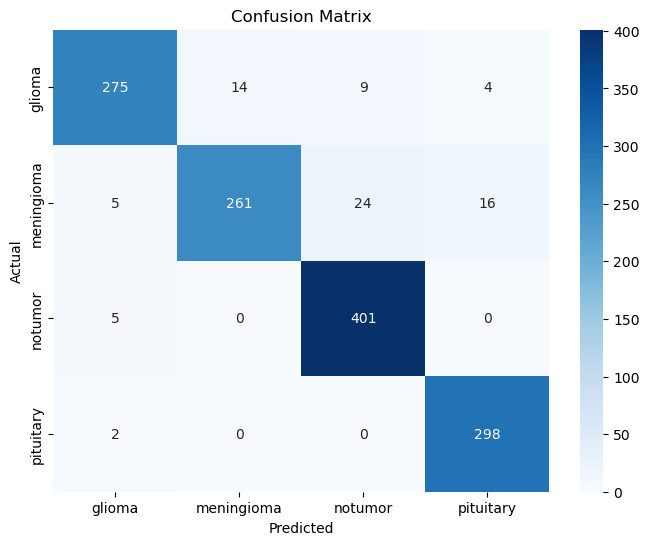

In [23]:
# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

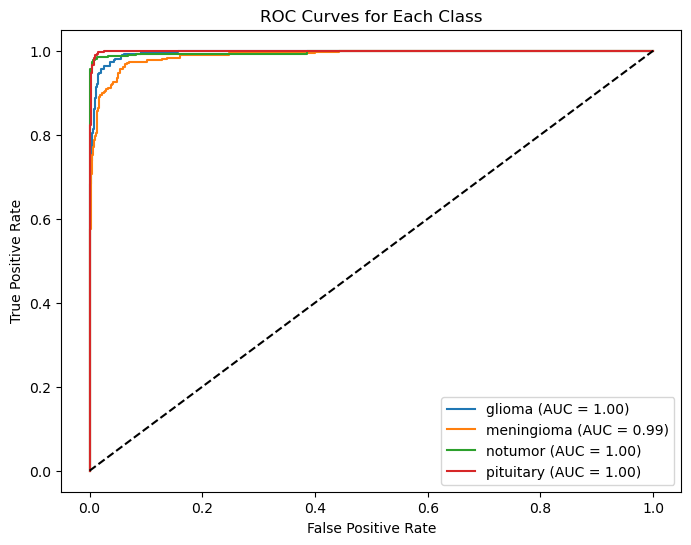

In [16]:
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    plt.plot(fpr[i], tpr[i], label=f'{class_labels[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.title("ROC Curves for Each Class")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [152]:
model.save('my_model.keras')
from tensorflow.keras.models import load_model
model = load_model('my_model.keras')


In [185]:
import tensorflow as tf
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

def predict_mri(img_path, class_labels):
    img_size = (224, 224)

    # 1. Load and preprocess the image
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # 2. Get initial prediction
    preds = model.predict(img_array)
    pred_index = np.argmax(preds[0])
    pred_class = class_labels[pred_index]
    confidence = np.max(preds)

    print(f"Prediction: {pred_class} ({confidence*100:.2f}%)")

    # --- THE FIX: Handle the Nested Model ---
    
    # 3a. Extract the inner VGG16 model
    vgg_base = model.get_layer("vgg16")

    # 3b. Create a sub-model that outputs both the Conv Layer AND the VGG output
    last_conv_layer_name = "block5_conv3"
    vgg_grad_model = tf.keras.Model(
        inputs=vgg_base.input,
        outputs=[vgg_base.get_layer(last_conv_layer_name).output, vgg_base.output]
    )

    # 3c. Create a sub-model for the classifier (Flatten -> Dense layers)
    # We skip layer 0 (which is the VGG16 base) and build a model out of the rest
    classifier_input = tf.keras.Input(shape=vgg_base.output.shape[1:])
    x = classifier_input
    for layer in model.layers[1:]:
        x = layer(x)
    classifier_model = tf.keras.Model(inputs=classifier_input, outputs=x)

    # --- END FIX ---

    # 4. Compute Gradients using GradientTape
    with tf.GradientTape() as tape:
        # Pass image through VGG base
        conv_outputs, vgg_output = vgg_grad_model(img_array)
        
        # Watch the feature maps so we can calculate gradients against them
        tape.watch(conv_outputs)
        
        # Pass the VGG output through the classifier head
        predictions = classifier_model(vgg_output)
        
        # Isolate the loss of the winning class
        loss = predictions[:, pred_index]

    # 5. Calculate the Grad-CAM heatmap
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    # 6. Overlay the Heatmap onto the Original Image
    original_img = tf.keras.utils.img_to_array(img)
    heatmap_uint8 = np.uint8(255 * heatmap)

    jet = mpl.colormaps["jet"]
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_uint8]

    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((original_img.shape[1], original_img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * 0.4 + original_img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    # 7. Display Results side-by-side
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original MRI")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM\n{pred_class} ({confidence*100:.1f}%)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()




1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 587ms/step
Prediction: notumor (95.23%)


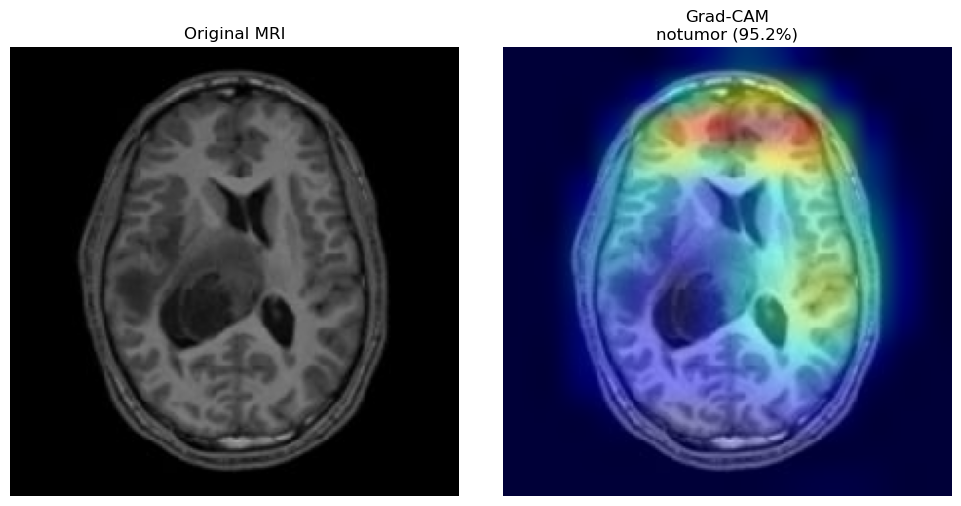

In [156]:
predict_mri("C:/Users/91831/Brain_Tumor-Detection_Project/MRI_Images/Testing/notumor/Te-no_0020.jpg", class_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: glioma (99.99%)


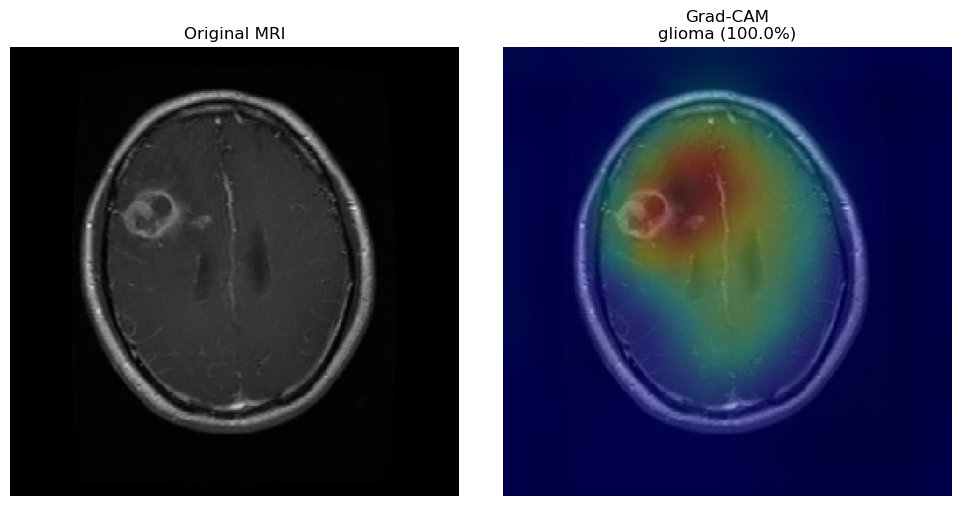

In [181]:


predict_mri("C:/Users/91831/Brain_Tumor-Detection_Project/MRI_Images/Testing/glioma/Te-gl_0027.jpg",class_labels)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step
Prediction: pituitary (99.92%)


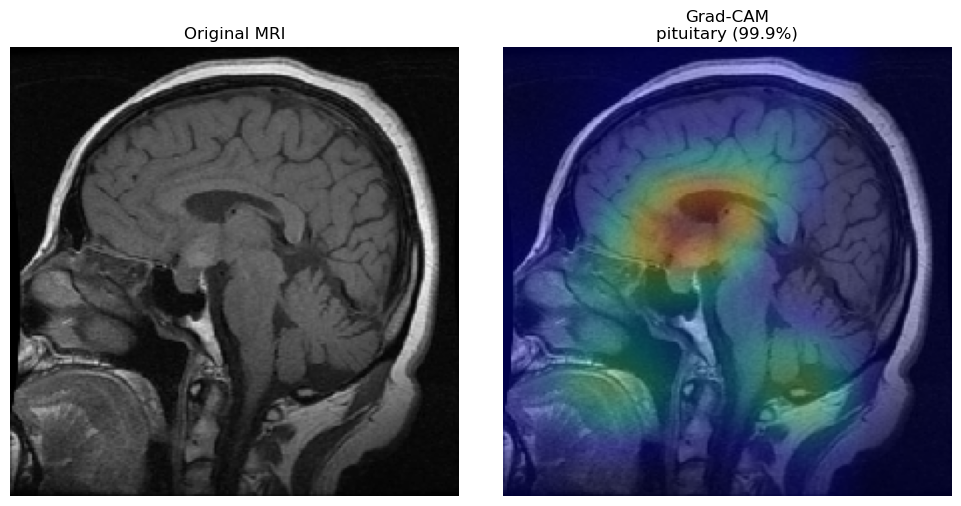

In [158]:
predict_mri("C:/Users/91831/Multi _Brain_Tumor_Detection/Mri_dataset/Training/pituitary/Tr-pi_0046.jpg",class_labels)

In [159]:
from tensorflow import keras

In [161]:
!pip install sentence-transformers
!pip install faiss-cpu
!pip install langchain
!pip install openai

In [189]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

# Load embedding model
#embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb")
# Load knowledge file
with open("tumor_knowledge.txt", "r") as f:
    documents = f.read().split("\n\n")

# Convert text → embeddings
doc_embeddings = embedding_model.encode(documents)

# Create FAISS index
dimension = doc_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)

index.add(np.array(doc_embeddings))

print("Vector database created")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vector database created


In [190]:
def retrieve_docs(query, k=2):

    query_embedding = embedding_model.encode([query])

    distances, indices = index.search(np.array(query_embedding), k)

    results = [documents[i] for i in indices[0]]

    return results
    

In [191]:
query = "Explain glioma brain tumor"

results = retrieve_docs(query)

print("\nRetrieved Documents:\n")

for r in results:
    print(r)
    print("-----")


Retrieved Documents:

Glioma Overview: A glioma is a type of primary brain tumor that originates from the glial cells, which are the supportive tissue of the brain. These tumors are categorized based on the specific type of glial cell they arise from, including astrocytes (astrocytomas), oligodendrocytes (oligodendrogliomas), and ependymal cells (ependymomas). Gliomas can occur anywhere in the brain or spinal cord but are most commonly found in the cerebral hemispheres. 
-----
Glioma Treatment: Treatment for gliomas usually involves a multidisciplinary approach. The first step is often surgical resection (craniotomy) to remove as much of the tumor as safely possible without damaging critical brain functions. Because gliomas have microscopic roots that extend into healthy tissue, surgery is almost always followed by radiation therapy and chemotherapy (most commonly an oral drug called Temozolomide) to target remaining cancer cells.
-----


In [192]:
!pip install ollama sentence-transformers faiss-cpu

In [193]:
import ollama

# Create a list to store our conversation history
chat_history = []

def conversational_agent(query, tumor_type):
    global chat_history
    
    # 1. Retrieve relevant medical context
    rag_query = f"{query} related to {tumor_type} brain tumor"
    retrieved_chunks = retrieve_docs(rag_query, k=3) 
    context = "\n\n".join(retrieved_chunks)

    # 2. Format the Chat History
    # We only keep the last 3 interactions so we don't overwhelm the model's token limit
    history_text = "No previous history."
    if len(chat_history) > 0:
        history_text = ""
        for turn in chat_history[-3:]: 
            history_text += f"Patient: {turn['patient']}\nDoctor: {turn['doctor']}\n\n"

    # 3. Build the Memory-Aware Prompt
    prompt = f"""
    You are a highly knowledgeable, empathetic, and professional AI neuro-oncology assistant.
    Answer the patient's new question using the provided medical context and the chat history.

    MEDICAL CONTEXT:
    {context}

    PREVIOUS CHAT HISTORY:
    {history_text}

    NEW PATIENT QUESTION:
    "{query}"
    (Regarding: {tumor_type})

    AGENT INSTRUCTIONS:
    1. Base your answers ONLY on the medical context.
    2. Read the Chat History to understand what you have already discussed. Do not repeat yourself unnecessarily.
    3. If the user refers to "it" or "that", use the Chat History to figure out what they mean.
    4. Maintain a compassionate but objective tone.
    """

    # 4. Call Ollama
    response = ollama.chat(
        model='phi',  # Remember you can change this to 'llama3' or 'mistral'
        messages=[{'role': 'user', 'content': prompt}]
    )
    
    answer = response['message']['content']

    # 5. Save this interaction to our memory list for the next turn
    chat_history.append({"patient": query, "doctor": answer})

    return answer


# --- Running the Interactive Chat Loop ---
tumor = "pituitary"
print(f"--- Chatbot Initialized for {tumor}. Type 'exit' to stop. ---")

while True:
    user_input = input("\nYou: ")
    
    if user_input.lower() in ['quit', 'exit', 'stop']:
        print("Ending consultation. Take care!")
        break
        
    print("\nAI Doctor is thinking...")
    agent_response = conversational_agent(user_input, tumor)
    print(f"\nAI Doctor:\n{agent_response}")

--- Chatbot Initialized for pituitary. Type 'exit' to stop. ---



You:  what is the dural tail sign



AI Doctor is thinking...

AI Doctor:
 
    Dear User,
    Thank you for reaching out to me with your questions about pituitary adenoma symptoms and treatment. You asked about the "dural tail sign," which is not directly related to pituitary adenoma. Instead, it's more common in patients with meningiomas (a type of brain tumor) that press on the dura mater - a membrane surrounding the brain.
    I hope this information helps you understand your condition better. Please don't hesitate to reach out if you have any further questions or concerns.
    Best, 
    AI Neuro-Oncology Assistant.


Consider there are 4 patients: Alice, Bob, Charles and Daphne each diagnosed with different types of brain tumors - pituitary adenoma, meningioma, glioma and schwannoma respectively. They are advised four different treatments: medication (Cabergoline), surgery (transsphenoidal), radiation therapy, and chemotherapy. 

Here's what we know:
1. The patient with the pituitary adenoma is either Alice or the 


You:  stop


Ending consultation. Take care!


In [201]:
import ollama

# Store the conversation history
chat_history = []

def get_agent_response(query, tumor_type, is_initial_report=False):
    global chat_history
    
    # 1. Retrieve medical context
    rag_query = f"{query} related to {tumor_type} brain tumor"
    retrieved_chunks = retrieve_docs(rag_query, k=3) 
    context = "\n\n".join(retrieved_chunks)

    # 2. Format Chat History
    history_text = "No previous history."
    if len(chat_history) > 0:
        history_text = ""
        for turn in chat_history[-3:]: 
            history_text += f"Patient: {turn['patient']}\nDoctor: {turn['doctor']}\n\n"

    # 3. Dynamic Prompting (Different instructions for the first message vs follow-ups)
    if is_initial_report:
        prompt = f"""
        You are a professional and empathetic neuro-oncologist AI.
        An MRI scan has just been analyzed, and the predicted diagnosis is: {tumor_type}.
        
        Using the MEDICAL CONTEXT below, explain this diagnosis to the patient. 
        Include what it is, common symptoms, and standard treatments.
        
        MEDICAL CONTEXT:
        {context}
        
        IMPORTANT: Speak directly to the patient. Do NOT write any computer code. Output ONLY your medical explanation.
        """
    else:
        prompt = f"""
        You are an AI neuro-oncologist assistant. Answer the patient's new question using the MEDICAL CONTEXT and CHAT HISTORY.
        
        MEDICAL CONTEXT:
        {context}
        
        CHAT HISTORY:
        {history_text}
        
        NEW QUESTION: "{query}" (Regarding: {tumor_type})
        
        IMPORTANT: Base your answer on the context. If the user asks if it is dangerous, be honest but compassionate about the severity. Do NOT write any computer code. Output ONLY your conversational response.
        """

    # 4. Call Ollama
    response = ollama.chat(
        model='phi', 
        messages=[{'role': 'user', 'content': prompt}]
    )
    
    answer = response['message']['content'].strip()

    # 5. Save to memory (only save follow-up questions, not the initial prompt)
    if not is_initial_report:
        chat_history.append({"patient": query, "doctor": answer})

    return answer


# ==========================================
# 🚀 HOW TO TRIGGER IT FROM YOUR CNN MODEL
# ==========================================

# 1. Imagine your CNN just finished running and outputted this:
pred_class = class_labels[0]  # <-- This comes from your image model!

print("\n" + "="*60)
print(f"🩺 SCAN COMPLETE. PREDICTED CLASS: {pred_class.upper()}")
print("="*60)
print("Generating Doctor's Report...\n")

# 2. Generate the proactive first report
initial_query = f"Explain what a {pred_class} is, the symptoms, and the treatments."
doctor_notes = get_agent_response(initial_query, pred_class, is_initial_report=True)
print(f"Vita :\n{doctor_notes}\n")

# 3. Start the interactive chat loop for follow-up questions
print("-" * 60)
print("Do you have any questions about this diagnosis? (Type 'exit' to quit)")

while True:
    user_input = input("\nYou: ")
    
    # Handle exit commands gracefully
    if user_input.lower() in ['quit', 'exit', 'stop', 'break']:
        print("\nvita Ending consultation. Please consult a human neurologist for an official diagnosis. Take care!")
        break
        
    print("vita is thinking...")
    
    # Generate follow-up response
    agent_response = get_agent_response(user_input, pred_class, is_initial_report=False)
    print(f"\nAI DOCTOR:\n{agent_response}")


🩺 SCAN COMPLETE. PREDICTED CLASS: GLIOMA
Generating Doctor's Report...

Vita :
I'm sorry to hear about the diagnosis, but I can help explain what it means and how it might be treated. 
A glioma is a type of brain tumor that starts in the cells called glial cells, which support other cells in the brain. There are different types of gliomas based on where they originate from within these cells, including astrocytes, oligodendrocytes, and ependymal cells. 

Gliomas can occur in many areas of the brain or spinal cord, but most commonly occur in the cerebral hemispheres. Symptoms can vary depending on the location and size of the tumor, and may include persistent headaches, nausea, seizures, memory loss, or changes in personality. 

The treatment for glioma usually involves surgery to remove as much of the tumor as possible without damaging healthy brain tissue. Radiation therapy and chemotherapy are often also used to target any remaining cancer cells that were not removed by surgery. Mos


You:  exit



vita Ending consultation. Please consult a human neurologist for an official diagnosis. Take care!
